# Dimensionality Reduction & Unsupervised Clustering

## Objective

This notebook applies Principal Component Analysis (PCA) and unsupervised clustering techniques to high-dimensional smartphone sensor data.

The analysis includes:

- Data preprocessing and standardization
- Principal Component Analysis (PCA)
- Explained variance and scree plot analysis
- K-Means clustering
- Elbow Method
- Silhouette Score analysis
- DBSCAN clustering
- Hierarchical clustering
- 2D and 3D cluster visualization
- Comparison of clustering approaches

## Dataset

Human Activity Recognition Using Smartphones

Source: UCI Machine Learning Repository

The dataset contains 10,299 observations and 561 numerical features.

The activity labels are not used as input to the unsupervised clustering algorithms. They may be used later for post-hoc interpretation of the discovered clusters.

In [8]:
from pathlib import Path
import pandas as pd

# Define dataset path
DATA_DIR = Path("../data/raw/UCI HAR Dataset")

# Load feature names
features = pd.read_csv(
    DATA_DIR / "features.txt",
    sep=r"\s+",
    header=None,
    names=["index", "feature"]
)

# Load activity labels
activity_labels = pd.read_csv(
    DATA_DIR / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["activity_id", "activity"]
)

# Load training and testing feature data
X_train = pd.read_csv(
    DATA_DIR / "train" / "X_train.txt",
    sep=r"\s+",
    header=None
)

X_test = pd.read_csv(
    DATA_DIR / "test" / "X_test.txt",
    sep=r"\s+",
    header=None
)

# Assign feature names
X_train.columns = features["feature"]
X_test.columns = features["feature"]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Number of features:", len(features))
print("\nActivity labels:")
print(activity_labels)

Training data shape: (7352, 561)
Testing data shape: (2947, 561)
Number of features: 561

Activity labels:
   activity_id            activity
0            1             WALKING
1            2    WALKING_UPSTAIRS
2            3  WALKING_DOWNSTAIRS
3            4             SITTING
4            5            STANDING
5            6              LAYING


In [9]:
# Basic data quality inspection

print("Missing values in training data:", X_train.isna().sum().sum())
print("Missing values in testing data:", X_test.isna().sum().sum())

print("\nFirst 5 feature names:")
print(features["feature"].head())

print("\nFirst 5 rows of training data:")
display(X_train.head())

Missing values in training data: 0
Missing values in testing data: 0

First 5 feature names:
0    tBodyAcc-mean()-X
1    tBodyAcc-mean()-Y
2    tBodyAcc-mean()-Z
3     tBodyAcc-std()-X
4     tBodyAcc-std()-Y
Name: feature, dtype: str

First 5 rows of training data:


feature,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [10]:
# Data quality and consistency checks

print("=== DATA QUALITY CHECKS ===")

# 1. Shape consistency
print("\n1. Shape consistency")
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Feature count matches:", X_train.shape[1] == X_test.shape[1])

# 2. Missing values
print("\n2. Missing values")
print("Training:", X_train.isna().sum().sum())
print("Testing:", X_test.isna().sum().sum())

# 3. Duplicate feature names
print("\n3. Duplicate feature names")
print("Duplicate feature names:", features["feature"].duplicated().sum())

# 4. Data types
print("\n4. Data types")
print("Non-numeric training columns:",
      X_train.select_dtypes(exclude="number").shape[1])

# 5. Constant features
print("\n5. Constant features")
constant_features = X_train.columns[X_train.nunique() <= 1]
print("Number of constant features:", len(constant_features))

# 6. Feature name consistency
print("\n6. Feature name consistency")
print("Train/Test column names match:",
      X_train.columns.equals(X_test.columns))

# Final validation
assert X_train.shape[1] == 561
assert X_test.shape[1] == 561
assert X_train.columns.equals(X_test.columns)
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("\n✓ All core validation checks passed.")

=== DATA QUALITY CHECKS ===

1. Shape consistency
Training features: (7352, 561)
Testing features: (2947, 561)
Feature count matches: True

2. Missing values
Training: 0
Testing: 0

3. Duplicate feature names
Duplicate feature names: 84

4. Data types
Non-numeric training columns: 0

5. Constant features
Number of constant features: 0

6. Feature name consistency
Train/Test column names match: True

✓ All core validation checks passed.


In [12]:
# Make feature names unique while preserving all 561 features
original_feature_names = features["feature"].tolist()

unique_feature_names = pd.Series(original_feature_names).astype(str)

# Add suffixes to duplicated names
seen = {}
final_feature_names = []

for name in unique_feature_names:
    if name not in seen:
        seen[name] = 0
        final_feature_names.append(name)
    else:
        seen[name] += 1
        final_feature_names.append(f"{name}__dup{seen[name]}")

X_train.columns = final_feature_names
X_test.columns = final_feature_names

print("Original feature count:", len(original_feature_names))
print("Final feature count:", len(final_feature_names))
print("Duplicate column names after renaming:",
      X_train.columns.duplicated().sum())

Original feature count: 561
Final feature count: 561
Duplicate column names after renaming: 0


In [13]:
from sklearn.preprocessing import StandardScaler

# Standardize using training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

print("\nTraining mean (approx.):", X_train_scaled.mean())
print("Training standard deviation (approx.):", X_train_scaled.std())

Training scaled shape: (7352, 561)
Testing scaled shape: (2947, 561)

Training mean (approx.): 1.1804271735699034e-17
Training standard deviation (approx.): 1.0


In [14]:
from sklearn.decomposition import PCA

# Fit PCA on the standardized training data
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of principal components:", X_train_pca.shape[1])
print("PCA output shape:", X_train_pca.shape)

Original number of features: 561
Number of principal components: 561
PCA output shape: (7352, 561)


In [16]:
# Inspect explained variance

explained_variance = pca.explained_variance_ratio_

print("Total explained variance:", explained_variance.sum())
print("First 10 components:")
print(explained_variance[:10])

Total explained variance: 0.9999999999999997
First 10 components:
[0.50781172 0.0658068  0.02806437 0.02503953 0.01888285 0.01724006
 0.01371011 0.01199078 0.0099586  0.00965087]


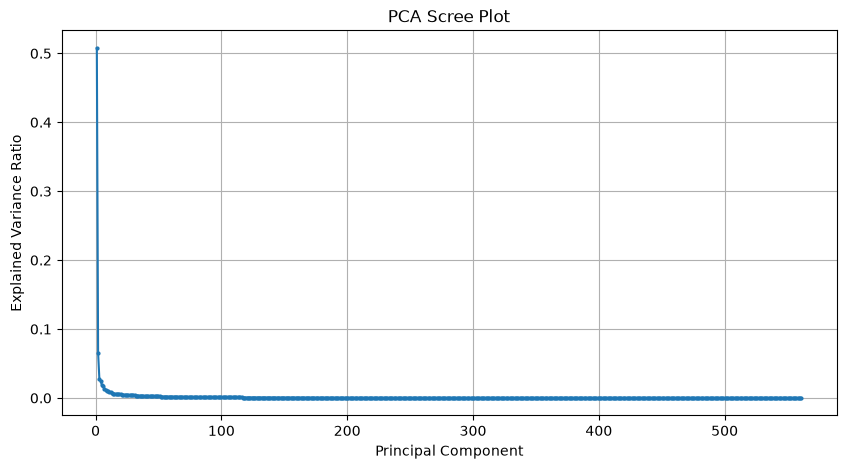

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
    markersize=2
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

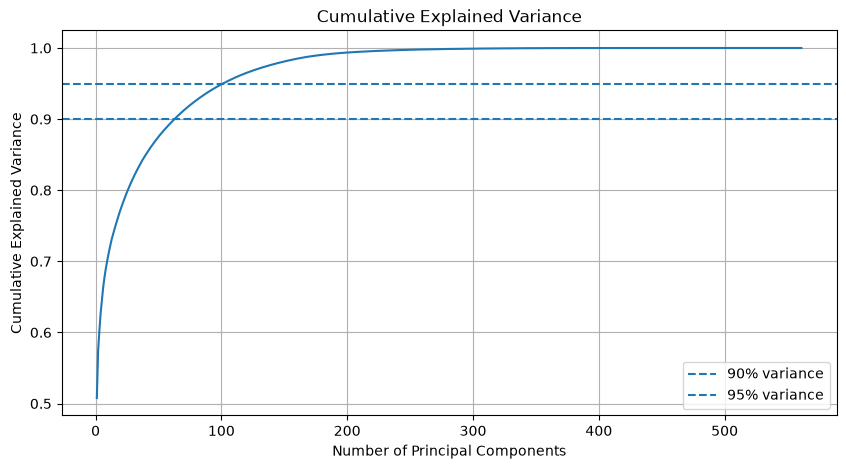

In [18]:
# Plot cumulative explained variance

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(y=0.90, linestyle="--", label="90% variance")
plt.axhline(y=0.95, linestyle="--", label="95% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Determine components required for common variance thresholds

components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components required for 90% variance:", components_90)
print("Components required for 95% variance:", components_95)

Components required for 90% variance: 63
Components required for 95% variance: 102


In [20]:
# Select PCA components retaining approximately 95% variance

n_components = components_95

X_train_pca_reduced = X_train_pca[:, :n_components]

# Transform test data using the already-fitted PCA model
X_test_pca = pca.transform(X_test_scaled)
X_test_pca_reduced = X_test_pca[:, :n_components]

print("Original feature dimensions:", X_train_scaled.shape[1])
print("Reduced feature dimensions:", X_train_pca_reduced.shape[1])

print("\nTraining reduced shape:", X_train_pca_reduced.shape)
print("Testing reduced shape:", X_test_pca_reduced.shape)

print(
    "\nVariance retained:",
    cumulative_variance[n_components - 1]
)

Original feature dimensions: 561
Reduced feature dimensions: 102

Training reduced shape: (7352, 102)
Testing reduced shape: (2947, 102)

Variance retained: 0.950755822025413


In [21]:
from sklearn.cluster import KMeans

# Range of cluster counts to evaluate
k_values = range(2, 11)

print("K-Means evaluation range:", list(k_values))
print("Input data shape:", X_train_pca_reduced.shape)

K-Means evaluation range: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Input data shape: (7352, 102)


In [22]:
# Fit K-Means for each candidate k

inertias = {}
kmeans_models = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_train_pca_reduced)
    
    inertias[k] = kmeans.inertia_
    kmeans_models[k] = kmeans

print("K-Means models fitted successfully.")

for k, inertia in inertias.items():
    print(f"k={k}: inertia={inertia:.2f}")

K-Means models fitted successfully.
k=2: inertia=2133133.68
k=3: inertia=1878866.60
k=4: inertia=1773541.99
k=5: inertia=1672340.52
k=6: inertia=1616137.38
k=7: inertia=1574488.34
k=8: inertia=1533301.82
k=9: inertia=1493942.79
k=10: inertia=1456333.72


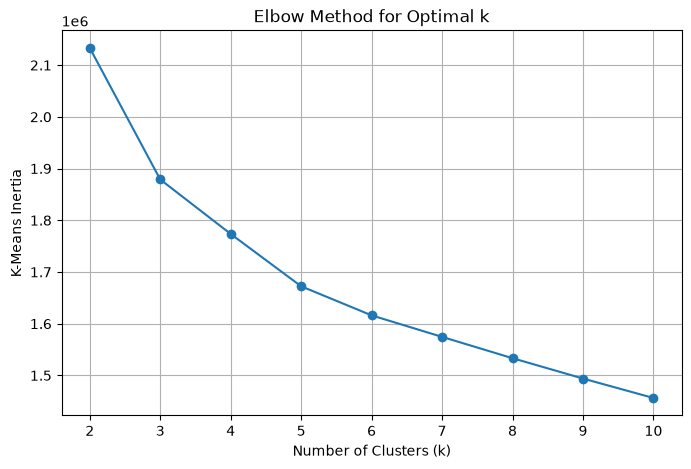

In [23]:
# Elbow Method for selecting the number of clusters

plt.figure(figsize=(8, 5))

plt.plot(
    list(inertias.keys()),
    list(inertias.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("K-Means Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [24]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for each candidate k
silhouette_scores = {}

for k, model in kmeans_models.items():
    score = silhouette_score(
        X_train_pca_reduced,
        model.labels_
    )
    silhouette_scores[k] = score

print("Silhouette scores:")

for k, score in silhouette_scores.items():
    print(f"k={k}: silhouette score={score:.4f}")

# Identify the best k based on silhouette score
best_k_silhouette = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print(
    f"\nBest k based on silhouette score: "
    f"{best_k_silhouette}"
)
print(
    f"Best silhouette score: "
    f"{silhouette_scores[best_k_silhouette]:.4f}"
)

Silhouette scores:
k=2: silhouette score=0.4154
k=3: silhouette score=0.3435
k=4: silhouette score=0.1737
k=5: silhouette score=0.1425
k=6: silhouette score=0.1215
k=7: silhouette score=0.0914
k=8: silhouette score=0.0953
k=9: silhouette score=0.0899
k=10: silhouette score=0.0941

Best k based on silhouette score: 2
Best silhouette score: 0.4154


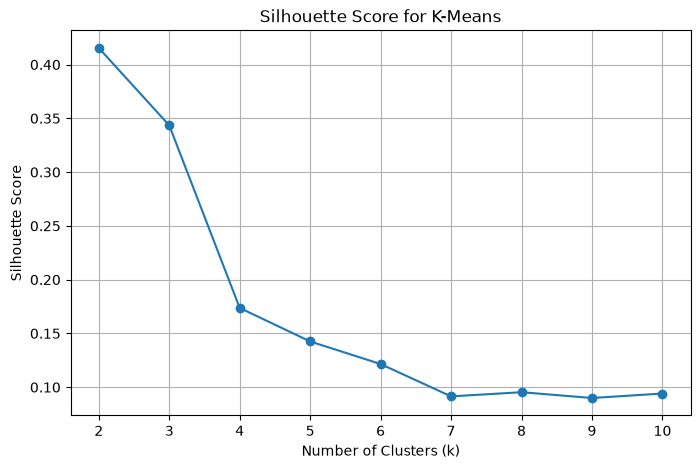

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [26]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN to the PCA-reduced training data
dbscan = DBSCAN(
    eps=3.0,
    min_samples=5,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_train_pca_reduced)

# Count clusters and noise points
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"Number of DBSCAN clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")
print(f"Noise percentage: {n_noise_dbscan / len(dbscan_labels) * 100:.2f}%")

Number of DBSCAN clusters: 0
Number of noise points: 7352
Noise percentage: 100.00%


In [27]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN to the PCA-reduced training data
dbscan = DBSCAN(
    eps=3.0,
    min_samples=5,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_train_pca_reduced)

# Count clusters and noise points
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"Number of DBSCAN clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")
print(f"Noise percentage: {n_noise_dbscan / len(dbscan_labels) * 100:.2f}%")

Number of DBSCAN clusters: 0
Number of noise points: 7352
Noise percentage: 100.00%


In [28]:
from sklearn.cluster import DBSCAN

eps_values = [3, 5, 7, 10, 15, 20]

dbscan_results = {}

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_train_pca_reduced)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    dbscan_results[eps] = {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_percentage": n_noise / len(labels) * 100
    }

    print(
        f"eps={eps}: "
        f"clusters={n_clusters}, "
        f"noise={n_noise}, "
        f"noise%={n_noise / len(labels) * 100:.2f}%"
    )

eps=3: clusters=0, noise=7352, noise%=100.00%
eps=5: clusters=0, noise=7352, noise%=100.00%
eps=7: clusters=4, noise=7332, noise%=99.73%
eps=10: clusters=27, noise=3959, noise%=53.85%
eps=15: clusters=4, noise=716, noise%=9.74%
eps=20: clusters=2, noise=159, noise%=2.16%


In [29]:
from sklearn.metrics import silhouette_score

dbscan_silhouette_scores = {}

for eps, result in dbscan_results.items():
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_train_pca_reduced)

    # Silhouette score requires at least 2 clusters
    # and excludes noise points (-1)
    non_noise_mask = labels != -1
    filtered_labels = labels[non_noise_mask]
    filtered_data = X_train_pca_reduced[non_noise_mask]

    if len(set(filtered_labels)) >= 2:
        score = silhouette_score(
            filtered_data,
            filtered_labels
        )
        dbscan_silhouette_scores[eps] = score

        print(
            f"eps={eps}: "
            f"silhouette score={score:.4f}"
        )
    else:
        print(
            f"eps={eps}: silhouette score cannot be calculated"
        )

eps=3: silhouette score cannot be calculated
eps=5: silhouette score cannot be calculated
eps=7: silhouette score=0.3033
eps=10: silhouette score=0.1219
eps=15: silhouette score=0.0575
eps=20: silhouette score=0.4256


In [30]:
# Final DBSCAN configuration
best_dbscan = DBSCAN(
    eps=20,
    min_samples=5,
    n_jobs=-1
)

dbscan_labels = best_dbscan.fit_predict(X_train_pca_reduced)

n_clusters_dbscan = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"Final DBSCAN clusters: {n_clusters_dbscan}")
print(f"Final DBSCAN noise points: {n_noise_dbscan}")
print(
    f"Final DBSCAN noise percentage: "
    f"{n_noise_dbscan / len(dbscan_labels) * 100:.2f}%"
)
print(
    f"Final DBSCAN silhouette score: "
    f"{dbscan_silhouette_scores[20]:.4f}"
)

Final DBSCAN clusters: 2
Final DBSCAN noise points: 159
Final DBSCAN noise percentage: 2.16%
Final DBSCAN silhouette score: 0.4256


In [31]:
from sklearn.cluster import AgglomerativeClustering

# Apply hierarchical (agglomerative) clustering
hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_train_pca_reduced
)

n_clusters_hierarchical = len(
    set(hierarchical_labels)
)

print(
    f"Number of hierarchical clusters: "
    f"{n_clusters_hierarchical}"
)

print(
    f"Cluster sizes:\n"
    f"{pd.Series(hierarchical_labels).value_counts().sort_index()}"
)

Number of hierarchical clusters: 2
Cluster sizes:
0    3286
1    4066
Name: count, dtype: int64


In [32]:
from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    X_train_pca_reduced,
    hierarchical_labels
)

print(
    f"Hierarchical clustering silhouette score: "
    f"{hierarchical_silhouette:.4f}"
)

Hierarchical clustering silhouette score: 0.4150


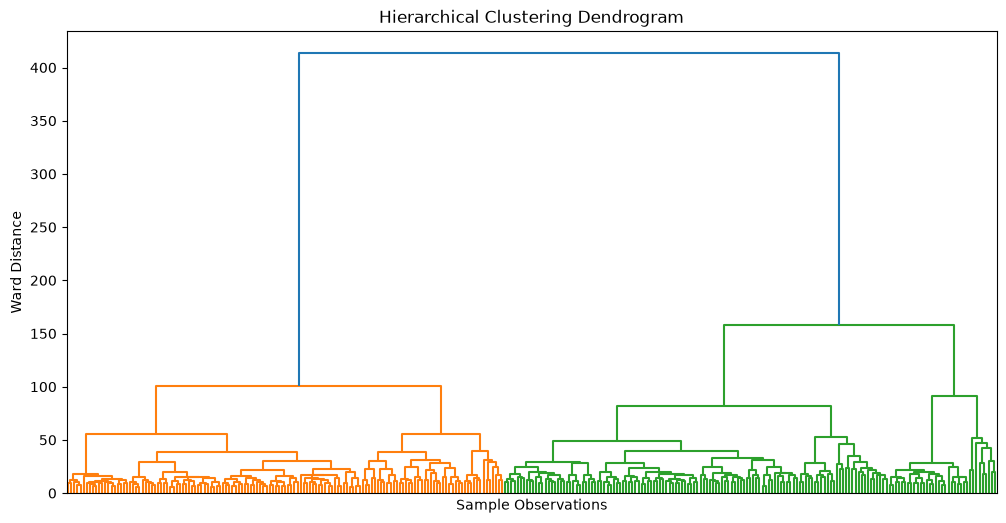

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a representative sample for dendrogram visualization
sample_size = 300

X_sample = X_train_pca_reduced[:sample_size]

# Compute hierarchical linkage
linkage_matrix = linkage(
    X_sample,
    method="ward"
)

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    no_labels=True,
    color_threshold=None
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Observations")
plt.ylabel("Ward Distance")

plt.show()

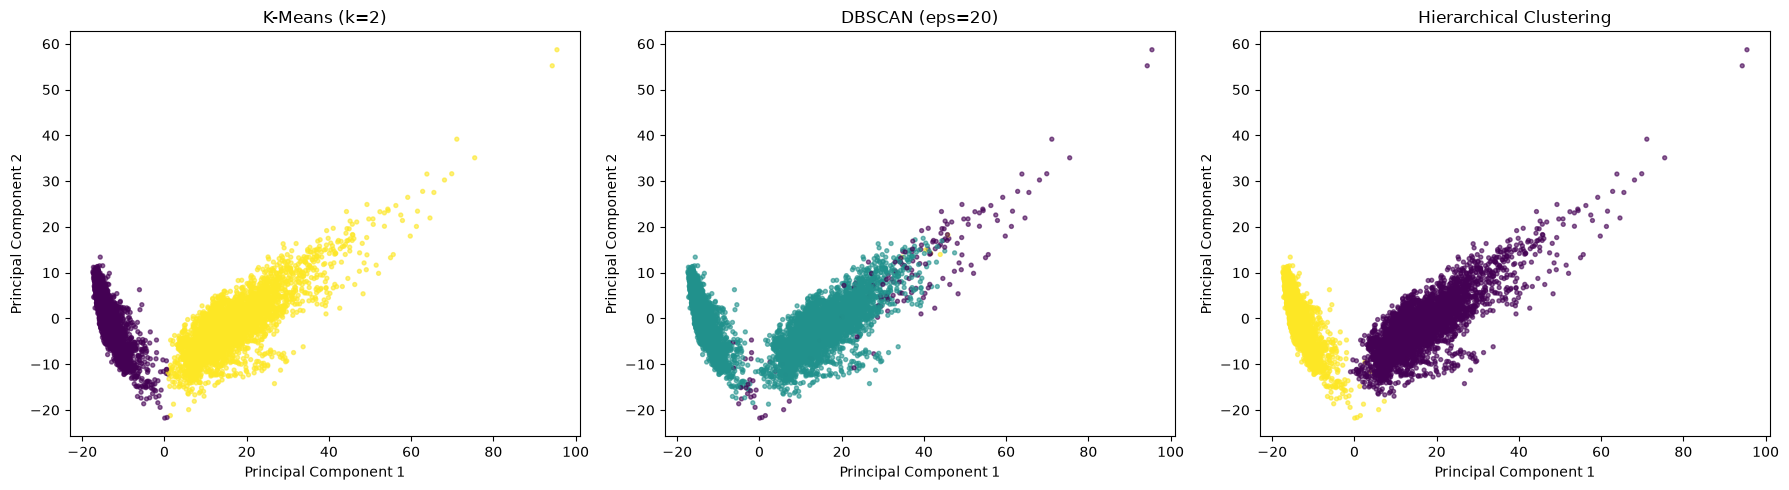

In [34]:
import matplotlib.pyplot as plt

# Use the first two principal components for visualization
X_2d = X_train_pca_reduced[:, :2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=kmeans_models[2].labels_,
    s=8,
    alpha=0.6
)
axes[0].set_title("K-Means (k=2)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# DBSCAN
axes[1].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=dbscan_labels,
    s=8,
    alpha=0.6
)
axes[1].set_title("DBSCAN (eps=20)")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

# Hierarchical
axes[2].scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=hierarchical_labels,
    s=8,
    alpha=0.6
)
axes[2].set_title("Hierarchical Clustering")
axes[2].set_xlabel("Principal Component 1")
axes[2].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()